In [1]:
%pip install seaborn xgboost


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import joblib
import xgboost as xgb
import scipy
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, ndcg_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Configure pandas display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 200)
pd.set_option('display.width', 1000)

DIRS = {
    'models': '../models',
    'results': '../results',
    'figures': '../results/figures',
    'ltr_data': '../data/processed/ltr_datasets',
    'split_data': '../data/processed/split_datasets'
}

for dir_path in DIRS.values():
    os.makedirs(dir_path, exist_ok=True)

print("Environment setup complete. Directories configured successfully.")

Environment setup complete. Directories configured successfully.


In [10]:
print("=" * 80)
print("STEP 0: VERIFY ACTUAL DATA STRUCTURE")
print("=" * 80)

DIRS = {
    'models': '../models',
    'results': '../results',
    'figures': '../results/figures',
    'ltr_data': '../data/processed/ltr_datasets',
    'split_data': '../data/processed/split_datasets'
}
for d in DIRS.values():
    os.makedirs(d, exist_ok=True)

# Load with CORRECT file names
ltr_train = pd.read_csv(f"{DIRS['ltr_data']}/ltr_train_dataset.csv")
ltr_val   = pd.read_csv(f"{DIRS['ltr_data']}/ltr_validation_dataset.csv")
ltr_test  = pd.read_csv(f"{DIRS['ltr_data']}/ltr_test_dataset.csv")
employee_candidate_pool = pd.read_csv(f"{DIRS['ltr_data']}/employee_candidate_pool.csv")

train_groups = json.load(open(f"{DIRS['ltr_data']}/train_group_sizes.json"))
val_groups   = json.load(open(f"{DIRS['ltr_data']}/validation_group_sizes.json"))
test_groups  = json.load(open(f"{DIRS['ltr_data']}/test_group_sizes.json"))

with open(f"{DIRS['ltr_data']}/ltr_feature_columns.json", "r") as f:
    feature_meta = json.load(f)

print(f"Train: {ltr_train.shape}, Val: {ltr_val.shape}, Test: {ltr_test.shape}")
print(f"\nTrain columns: {list(ltr_train.columns)}")
print(f"\nFeature meta keys: {list(feature_meta.keys()) if isinstance(feature_meta, dict) else 'is list'}")

# Check what's available
print(f"\n'sample_weight' in train: {'sample_weight' in ltr_train.columns}")
print(f"'employee_historical_task_count' in train: {'employee_historical_task_count' in ltr_train.columns}")
print(f"'employee_project_task_count' in test: {'employee_project_task_count' in ltr_test.columns}")

print(f"\nEmployee pool: {employee_candidate_pool.shape}")
print(f"Pool columns: {list(employee_candidate_pool.columns)}")

print(f"\nGroup sizes - Train: {len(train_groups)} groups, sum={sum(train_groups)}")
print(f"Group sizes - Val: {len(val_groups)} groups, sum={sum(val_groups)}")
print(f"Group sizes - Test: {len(test_groups)} groups, sum={sum(test_groups)}")

# Relevance distribution
for name, df in [("train", ltr_train), ("val", ltr_val), ("test", ltr_test)]:
    print(f"\n{name} positive rate: {df['relevance'].mean():.3f} ({df['relevance'].sum()} / {len(df)})")


STEP 0: VERIFY ACTUAL DATA STRUCTURE
Train: (36605, 65), Val: (7829, 65), Test: (7827, 65)

Train columns: ['Task_ID', 'Employee_ID', 'relevance', 'Hours_Spent', 'FLAG_LEAKAGE_Timesheet_Work_Logs', 'Task_Priority', 'Estimated_Planned_Hours', 'FLAG_LEAKAGE_Actual_Hours_Spent', 'FLAG_LEAKAGE_Timesheet_Logs_Count', 'FLAG_LEAKAGE_Task_Stage', 'FLAG_LEAKAGE_All_Collaborating_Employees', 'Task_Text_Length', 'Task_Word_Count', 'Task_Description_Length', 'Task_Name_Length', 'Has_Task_Description', 'Created_Year', 'Created_Month', 'Created_DayOfWeek', 'Created_Quarter', 'Days_To_Deadline', 'Has_Deadline', 'Planned_Hours_Log', 'Planned_Task_Size', 'Task_Skill_Count', 'Skill_Odoo_ERP_Development', 'Skill_Database_Management', 'Skill_Server_Administration', 'Skill_Project_Management', 'Skill_Software_Testing', 'Skill_Web_Development', 'Skill_Client_and_Functional_Support', 'Skill_Documentation', 'Skill_Training_and_Mentorship', 'Project_Task_Count_Train', 'Project_Avg_Skill_Count_Train', 'Project_

In [11]:
print("=" * 80)
print("STEP 1: CONFIGURE FEATURES")
print("=" * 80)

# Handle both dict and list formats
if isinstance(feature_meta, dict):
    if "feature_cols" in feature_meta:
        FEATURE_COLS = feature_meta["feature_cols"]
    elif "features" in feature_meta:
        FEATURE_COLS = feature_meta["features"]
    else:
        FEATURE_COLS = list(feature_meta.values())[0]
elif isinstance(feature_meta, list):
    FEATURE_COLS = feature_meta
else:
    raise ValueError(f"Unexpected format: {type(feature_meta)}")

# Exclude non-feature columns
EXCLUDE = ["Task_ID", "Employee_ID", "relevance", "Employee_Name", 
           "Assigned_Employee_ID", "Assigned_Employee_Name"]
FEATURE_COLS = [c for c in FEATURE_COLS if c not in EXCLUDE]

print(f"Using {len(FEATURE_COLS)} features")

# Verify all features exist
for name, df in [("train", ltr_train), ("val", ltr_val), ("test", ltr_test)]:
    missing = [c for c in FEATURE_COLS if c not in df.columns]
    if missing:
        print(f"  ⚠ {name} missing {len(missing)} features: {missing[:5]}")
    else:
        print(f"  ✓ {name} has all features")


STEP 1: CONFIGURE FEATURES
Using 56 features
  ✓ train has all features
  ✓ val has all features
  ✓ test has all features


In [12]:
print("--- Data Validation ---")

print(f"Train shape: {ltr_train.shape}")
print(f"Validation shape: {ltr_val.shape}")
print(f"Test shape: {ltr_test.shape}")

print(f"Number of unique train tasks: {ltr_train['Task_ID'].nunique()}")
print(f"Number of unique validation tasks: {ltr_val['Task_ID'].nunique()}")
print(f"Number of unique test tasks: {ltr_test['Task_ID'].nunique()}")

print(f"Number of employees: {len(employee_candidate_pool)}")

print(f"Number of positive labels (train): {(ltr_train['relevance'] == 1).sum()}")
print(f"Number of negative labels (train): {(ltr_train['relevance'] == 0).sum()}")

assert "Task_ID" in ltr_train.columns
assert "Employee_ID" in ltr_train.columns
assert "relevance" in ltr_train.columns

exclude_columns = [
    "Task_ID", 
    "Employee_ID", 
    "relevance", 
    "Employee_Name", 
    "Assigned_Employee_ID", 
    "Assigned_Employee_Name"
]

FEATURE_COLS = [col for col in FEATURE_COLS if col not in exclude_columns]

missing_in_train = [col for col in FEATURE_COLS if col not in ltr_train.columns]
missing_in_val = [col for col in FEATURE_COLS if col not in ltr_val.columns]
missing_in_test = [col for col in FEATURE_COLS if col not in ltr_test.columns]

assert len(missing_in_train) == 0, f"Features missing in train: {missing_in_train}"
assert len(missing_in_val) == 0, f"Features missing in validation: {missing_in_val}"
assert len(missing_in_test) == 0, f"Features missing in test: {missing_in_test}"

print(f"✅ Data validation passed! {len(FEATURE_COLS)} features verified and active.")

--- Data Validation ---
Train shape: (36605, 65)
Validation shape: (7829, 65)
Test shape: (7827, 65)
Number of unique train tasks: 1709
Number of unique validation tasks: 366
Number of unique test tasks: 367
Number of employees: 49
Number of positive labels (train): 2425
Number of negative labels (train): 34180
✅ Data validation passed! 56 features verified and active.


--- Selecting Numeric Features for Correlation Analysis ---
Selected 56 numeric features for correlation analysis.
--- Generating Correlation Matrix ---


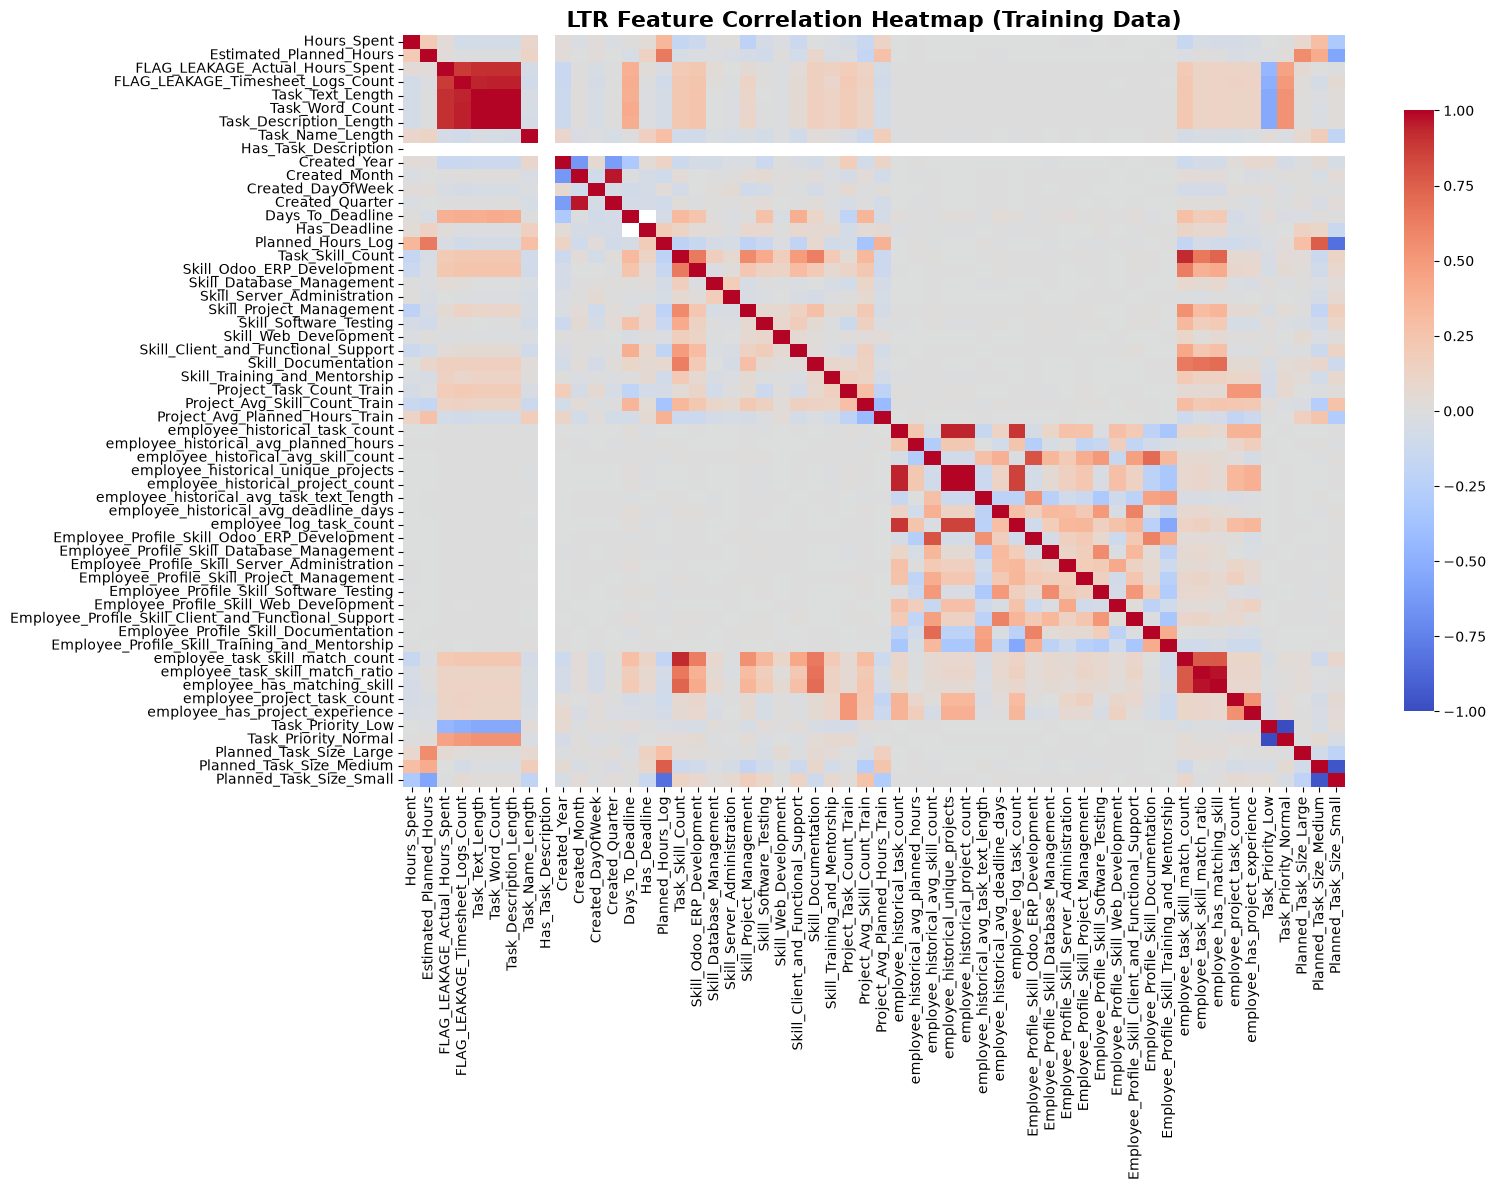

Heatmap saved to: ../results/figures/feature_correlation_heatmap.png


In [13]:
print("--- Selecting Numeric Features for Correlation Analysis ---")

numeric_feature_columns = (
    ltr_train[FEATURE_COLS]
    .select_dtypes(include=[np.number])
    .columns
    .tolist()
)

print(f"Selected {len(numeric_feature_columns)} numeric features for correlation analysis.")

print("--- Generating Correlation Matrix ---")

correlation_matrix = ltr_train[numeric_feature_columns].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(
    correlation_matrix, 
    cmap="coolwarm", 
    vmin=-1, 
    vmax=1, 
    cbar_kws={'shrink': .8}
)
plt.title("LTR Feature Correlation Heatmap (Training Data)", fontsize=16, fontweight="bold")
plt.tight_layout()

heatmap_path = f"{DIRS['figures']}/feature_correlation_heatmap.png"
plt.savefig(heatmap_path, dpi=300)
plt.show()

print(f"Heatmap saved to: {heatmap_path}")

In [14]:
print("--- Identifying Highly Correlated Feature Pairs ---")

upper_triangle = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)

high_correlation_pairs = (
    upper_triangle
    .stack()
    .reset_index()
)

high_correlation_pairs.columns = [
    "Feature_1",
    "Feature_2",
    "Correlation"
]

high_correlation_pairs = high_correlation_pairs[
    high_correlation_pairs["Correlation"].abs() >= 0.85
].sort_values(by="Correlation", key=abs, ascending=False)

high_correlation_path = f"{DIRS['results']}/high_correlation_pairs.csv"
high_correlation_pairs.to_csv(high_correlation_path, index=False)
print(f"Highly correlated feature pairs saved to: {high_correlation_path}")

display(high_correlation_pairs)

--- Identifying Highly Correlated Feature Pairs ---
Highly correlated feature pairs saved to: ../results/high_correlation_pairs.csv


,Feature_1,Feature_2,Correlation
1825,employee_historical_unique_projects,employee_historical_project_count,1.000000
2908,Task_Priority_Low,Task_Priority_Normal,-1.000000
230,Task_Text_Length,Task_Description_Length,0.999849
286,Task_Word_Count,Task_Description_Length,0.998940
229,Task_Text_Length,Task_Word_Count,0.998931
2680,employee_task_skill_match_ratio,employee_has_matching_skill,0.972919
572,Created_Month,Created_Quarter,0.963053
3079,Planned_Task_Size_Medium,Planned_Task_Size_Small,-0.956279
173,FLAG_LEAKAGE_Timesheet_Logs_Count,Task_Word_Count,0.948275
174,FLAG_LEAKAGE_Timesheet_Logs_Count,Task_Description_Length,0.945630


In [15]:
print("--- Calculating Feature-Target Correlation ---")

feature_target_correlation = (
    ltr_train[numeric_feature_columns + ["relevance"]]
    .corr()["relevance"]
    .drop("relevance")
    .sort_values(key=abs, ascending=False)
)

print(feature_target_correlation.head(15))

target_corr_path = f"{DIRS['results']}/feature_target_correlation.csv"
feature_target_correlation.to_csv(target_corr_path, header=["Correlation"])
print(f"\nFeature-target correlation saved to: {target_corr_path}")

--- Calculating Feature-Target Correlation ---
employee_has_project_experience                   0.391886
employee_project_task_count                       0.382526
employee_historical_task_count                    0.239731
employee_historical_unique_projects               0.227207
employee_historical_project_count                 0.227207
employee_log_task_count                           0.217607
FLAG_LEAKAGE_Timesheet_Logs_Count                 0.162726
FLAG_LEAKAGE_Actual_Hours_Spent                   0.155741
Task_Word_Count                                   0.151078
Task_Description_Length                           0.150262
Task_Text_Length                                  0.149878
employee_task_skill_match_count                   0.109765
employee_task_skill_match_ratio                   0.082410
Employee_Profile_Skill_Training_and_Mentorship   -0.080975
Project_Task_Count_Train                          0.080805
Name: relevance, dtype: float64

Feature-target correlation saved to

In [16]:
print("--- Step 8. Verify Feature Safety ---")

prohibited_columns = [
    "Task_ID", "Employee_ID", "Employee_Name", "Assigned_Employee_ID",
    "Assigned_Employee_Name", "Hours_Spent", "Actual_Hours_Spent", 
    "Timesheet_Work_Logs", "Timesheet_Logs_Count", "Task_Stage", 
    "All_Collaborating_Employees", "Work_Description", "relevance",
    "Task_Priority_Normal", "Task_Word_Count", "Task_Description_Length", 
    "Created_Quarter", "employee_historical_task_count", 
    "employee_historical_project_count"
]

prohibited_flags = [col for col in numeric_feature_columns if 'FLAG_LEAKAGE' in col]

all_prohibited = prohibited_columns + prohibited_flags

final_feature_columns = [col for col in numeric_feature_columns if col not in all_prohibited]

leakage_detected = [col for col in final_feature_columns if col in all_prohibited]

if leakage_detected:
    raise ValueError(f"FATAL LEAKAGE DETECTED: {leakage_detected}. Stop execution and fix the dataset!")

print(f"Number of final model features: {len(final_feature_columns)}\n")
print("List of final model features:")
for idx, feature in enumerate(final_feature_columns, 1):
    print(f"  {idx:02d}. {feature}")

--- Step 8. Verify Feature Safety ---
Number of final model features: 47

List of final model features:
  01. Estimated_Planned_Hours
  02. Task_Text_Length
  03. Task_Name_Length
  04. Has_Task_Description
  05. Created_Year
  06. Created_Month
  07. Created_DayOfWeek
  08. Days_To_Deadline
  09. Has_Deadline
  10. Planned_Hours_Log
  11. Task_Skill_Count
  12. Skill_Odoo_ERP_Development
  13. Skill_Database_Management
  14. Skill_Server_Administration
  15. Skill_Project_Management
  16. Skill_Software_Testing
  17. Skill_Web_Development
  18. Skill_Client_and_Functional_Support
  19. Skill_Documentation
  20. Skill_Training_and_Mentorship
  21. Project_Task_Count_Train
  22. Project_Avg_Skill_Count_Train
  23. Project_Avg_Planned_Hours_Train
  24. employee_historical_avg_planned_hours
  25. employee_historical_avg_skill_count
  26. employee_historical_unique_projects
  27. employee_historical_avg_task_text_length
  28. employee_historical_avg_deadline_days
  29. employee_log_task_co

In [17]:
print("=" * 80)
print("STEP 2: PREPARE TRAINING DATA")
print("=" * 80)

X_train = ltr_train[FEATURE_COLS].copy()
y_train = ltr_train["relevance"].astype(int)
X_val = ltr_val[FEATURE_COLS].copy()
y_val = ltr_val["relevance"].astype(int)
X_test = ltr_test[FEATURE_COLS].copy()
y_test = ltr_test["relevance"].astype(int)

print(f"X_train: {X_train.shape}, positive rate: {y_train.mean():.3f}")
print(f"X_val:   {X_val.shape}, positive rate: {y_val.mean():.3f}")
print(f"X_test:  {X_test.shape}, positive rate: {y_test.mean():.3f}")
print("Note: No sample_weight column — using class_weight='balanced' instead")

# Impute for sklearn models
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")

X_train_sklearn = pd.DataFrame(imputer.fit_transform(X_train), columns=FEATURE_COLS)
X_val_sklearn   = pd.DataFrame(imputer.transform(X_val), columns=FEATURE_COLS)
X_test_sklearn  = pd.DataFrame(imputer.transform(X_test), columns=FEATURE_COLS)

# XGBoost uses raw data
X_train_xgb = X_train.copy()
X_val_xgb   = X_val.copy()
X_test_xgb  = X_test.copy()


STEP 2: PREPARE TRAINING DATA
X_train: (36605, 56), positive rate: 0.066
X_val:   (7829, 56), positive rate: 0.065
X_test:  (7827, 56), positive rate: 0.062
Note: No sample_weight column — using class_weight='balanced' instead


In [18]:
print("--- Step 10. Create a Non-ML Baseline ---")

from sklearn.metrics import ndcg_score

def evaluate_ranking_metrics(df, score_col, k_list=[1, 3, 5]):
    """
    Evaluates ranking performance using Hit@K, MRR, and NDCG.
    Groups predictions by Task_ID and compares sorted scores against relevance.
    """
    results = {f'Hit@{k}': [] for k in k_list}
    results['MRR'] = []
    results['NDCG@5'] = []
    
    for task_id, group in df.groupby('Task_ID'):
        y_true = group['relevance'].values
        y_scores = group[score_col].values
        
        sorted_indices = np.argsort(-y_scores, kind='mergesort')
        sorted_y_true = y_true[sorted_indices]
        
        for k in k_list:
            results[f'Hit@{k}'].append(1 if np.sum(sorted_y_true[:k]) > 0 else 0)
            
        relevant_ranks = np.where(sorted_y_true == 1)[0]
        if len(relevant_ranks) > 0:
            first_relevant_rank = relevant_ranks[0] + 1
            results['MRR'].append(1.0 / first_relevant_rank)
        else:
            results['MRR'].append(0.0)
            
        if np.sum(y_true) > 0:
            # sklearn's ndcg_score expects 2D arrays: shape (n_samples, n_labels)
            results['NDCG@5'].append(ndcg_score([y_true], [y_scores], k=5))
        else:
            results['NDCG@5'].append(0.0)
            
    # Calculate and return means across all tasks
    return {k: round(np.mean(v), 4) for k, v in results.items()}

# --- NEW: Helper function to print metrics clearly ---
def print_metrics_clearly(metrics_dict, title):
    print(f"\n{title}")
    print("=" * 40)
    for metric, value in metrics_dict.items():
        print(f"| {metric:<10} | {value:>10.4f} |")
    print("=" * 40)

# 1. Global Historical Frequency Baseline
global_baseline_metrics = evaluate_ranking_metrics(ltr_test, 'employee_historical_task_count')
print_metrics_clearly(global_baseline_metrics, "GLOBAL HISTORICAL BASELINE")

# 2. Project-Aware Historical Frequency Baseline
max_global_tasks = ltr_train['employee_historical_task_count'].max()
multiplier = max_global_tasks * 10 # Guarantee project experience outweighs global experience

ltr_test['project_aware_score'] = (
    (ltr_test['employee_project_task_count'] * multiplier) + 
    ltr_test['employee_historical_task_count']
)

project_baseline_metrics = evaluate_ranking_metrics(ltr_test, 'project_aware_score')
print_metrics_clearly(project_baseline_metrics, "PROJECT-AWARE BASELINE")

# 3. Save Baseline Results
baseline_results = {
    "global_historical_baseline": global_baseline_metrics,
    "project_aware_baseline": project_baseline_metrics
}

baseline_path = f"{DIRS['results']}/baseline_results.json"
with open(baseline_path, 'w') as f:
    json.dump(baseline_results, f, indent=4)

print(f"\n✅ Baseline results saved to: {baseline_path}")

--- Step 10. Create a Non-ML Baseline ---

GLOBAL HISTORICAL BASELINE
| Hit@1      |     0.2207 |
| Hit@3      |     0.4523 |
| Hit@5      |     0.6431 |
| MRR        |     0.4055 |
| NDCG@5     |     0.4072 |

PROJECT-AWARE BASELINE
| Hit@1      |     0.5313 |
| Hit@3      |     0.8147 |
| Hit@5      |     0.9210 |
| MRR        |     0.6914 |
| NDCG@5     |     0.7134 |

✅ Baseline results saved to: ../results/baseline_results.json


In [19]:
print("=" * 80)
print("STEP 3: LOGISTIC REGRESSION (BALANCED)")
print("=" * 80)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logistic_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42,
        solver='lbfgs',
        n_jobs=-1
    ))
])

logistic_pipeline.fit(X_train_sklearn, y_train)

y_test_pred_proba = logistic_pipeline.predict_proba(X_test_sklearn)[:, 1]

logistic_predictions = ltr_test[['Task_ID', 'Employee_ID', 'relevance']].copy()
logistic_predictions['prediction_score'] = y_test_pred_proba
logistic_predictions['predicted_label'] = (y_test_pred_proba > 0.5).astype(int)

logistic_predictions.to_csv(f"{DIRS['results']}/logistic_predictions.csv", index=False)

if 'evaluate_ranking_metrics' in globals():
    logreg_metrics = evaluate_ranking_metrics(logistic_predictions, 'prediction_score')
    if 'print_metrics_clearly' in globals():
        print_metrics_clearly(logreg_metrics, "LOGISTIC REGRESSION (BALANCED)")


STEP 3: LOGISTIC REGRESSION (BALANCED)


/home/chandima-bandara/Desktop/intelligent-employee-task-allocation/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1435: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



LOGISTIC REGRESSION (BALANCED)
| Hit@1      |     0.5422 |
| Hit@3      |     0.8229 |
| Hit@5      |     0.9046 |
| MRR        |     0.6963 |
| NDCG@5     |     0.7127 |


In [20]:
print("--- Step 13. Compare Model Against Baseline ---")

baseline_path = f"{DIRS['results']}/baseline_results.json"
with open(baseline_path, 'r') as f:
    saved_baselines = json.load(f)

project_baseline = saved_baselines["project_aware_baseline"]

comparison_df = pd.DataFrame({
    "Metric": list(project_baseline.keys()),
    "Project_Aware_Baseline": list(project_baseline.values()),
    "Logistic_Regression": list(logreg_metrics.values())
})

comparison_df["Difference"] = (
    comparison_df["Logistic_Regression"] - comparison_df["Project_Aware_Baseline"]
)

print("\n🔍 LOGISTIC REGRESSION vs PROJECT-AWARE BASELINE")
print("=" * 65)
print(comparison_df.to_string(index=False, float_format="{:.4f}".format))
print("=" * 65)

if comparison_df.loc[comparison_df['Metric'] == 'NDCG@5', 'Difference'].values[0] < 0:
    print("\nInsight: Logistic Regression lost to the baseline on NDCG@5.")
    print("Linear models struggle to rank imbalanced binary labels properly.")

--- Step 13. Compare Model Against Baseline ---

🔍 LOGISTIC REGRESSION vs PROJECT-AWARE BASELINE
Metric  Project_Aware_Baseline  Logistic_Regression  Difference
 Hit@1                  0.5313               0.5422      0.0109
 Hit@3                  0.8147               0.8229      0.0082
 Hit@5                  0.9210               0.9046     -0.0164
   MRR                  0.6914               0.6963      0.0049
NDCG@5                  0.7134               0.7127     -0.0007

Insight: Logistic Regression lost to the baseline on NDCG@5.
Linear models struggle to rank imbalanced binary labels properly.


In [21]:
print("=" * 80)
print("STEP 4: RANDOM FOREST (BALANCED + REGULARIZED)")
print("=" * 80)

from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(X_train_sklearn, y_train)

y_test_pred_proba = random_forest_model.predict_proba(X_test_sklearn)[:, 1]

random_forest_predictions = ltr_test[['Task_ID', 'Employee_ID', 'relevance']].copy()
random_forest_predictions['prediction_score'] = y_test_pred_proba
random_forest_predictions['predicted_label'] = (y_test_pred_proba > 0.5).astype(int)

random_forest_predictions.to_csv(f"{DIRS['results']}/random_forest_predictions.csv", index=False)

rf_feature_importance = pd.DataFrame({
    "feature": FEATURE_COLS,
    "importance": random_forest_model.feature_importances_
}).sort_values("importance", ascending=False)
rf_feature_importance.to_csv(f"{DIRS['results']}/random_forest_feature_importance.csv", index=False)

if 'evaluate_ranking_metrics' in globals():
    rf_metrics = evaluate_ranking_metrics(random_forest_predictions, 'prediction_score')
    if 'print_metrics_clearly' in globals():
        print_metrics_clearly(rf_metrics, "RANDOM FOREST (BALANCED)")


STEP 4: RANDOM FOREST (BALANCED + REGULARIZED)

RANDOM FOREST (BALANCED)
| Hit@1      |     0.6812 |
| Hit@3      |     0.8992 |
| Hit@5      |     0.9646 |
| MRR        |     0.7962 |
| NDCG@5     |     0.8101 |


In [22]:
print("=" * 80)
print("STEP 5: XGBOOST CLASSIFIER")
print("=" * 80)

from xgboost import XGBClassifier

xgb_classifier = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)

xgb_classifier.fit(
    X_train_xgb, y_train,
    eval_set=[(X_val_xgb, y_val)],
    verbose=False
)

y_test_pred_proba = xgb_classifier.predict_proba(X_test_xgb)[:, 1]

xgboost_predictions = ltr_test[['Task_ID', 'Employee_ID', 'relevance']].copy()
xgboost_predictions['prediction_score'] = y_test_pred_proba
xgboost_predictions['predicted_label'] = (y_test_pred_proba > 0.5).astype(int)

xgboost_predictions.to_csv(f"{DIRS['results']}/xgboost_predictions.csv", index=False)

xgb_feature_importance = pd.DataFrame({
    "feature": FEATURE_COLS,
    "importance": xgb_classifier.feature_importances_
}).sort_values("importance", ascending=False)
xgb_feature_importance.to_csv(f"{DIRS['results']}/xgboost_feature_importance.csv", index=False)

if 'evaluate_ranking_metrics' in globals():
    xgb_metrics = evaluate_ranking_metrics(xgboost_predictions, 'prediction_score')
    if 'print_metrics_clearly' in globals():
        print_metrics_clearly(xgb_metrics, "XGBOOST CLASSIFIER")


STEP 5: XGBOOST CLASSIFIER

XGBOOST CLASSIFIER
| Hit@1      |     0.6703 |
| Hit@3      |     0.9183 |
| Hit@5      |     0.9673 |
| MRR        |     0.7980 |
| NDCG@5     |     0.8167 |


In [23]:
print("=" * 80)
print("STEP 6: XGBOOST RANKER (PRIMARY MODEL)")
print("=" * 80)

import xgboost as xgb_native

# Build DMatrix with group structure
dtrain_rank = xgb_native.DMatrix(X_train_xgb, label=y_train, feature_names=FEATURE_COLS)
dval_rank   = xgb_native.DMatrix(X_val_xgb,   label=y_val,   feature_names=FEATURE_COLS)
dtest_rank  = xgb_native.DMatrix(X_test_xgb,  label=y_test,  feature_names=FEATURE_COLS)

# Set group sizes
dtrain_rank.set_group(train_groups)
dval_rank.set_group(val_groups)
dtest_rank.set_group(test_groups)

# Verify alignment
assert sum(train_groups) == len(X_train_xgb), f"Train group mismatch: {sum(train_groups)} vs {len(X_train_xgb)}"
assert sum(val_groups) == len(X_val_xgb), f"Val group mismatch: {sum(val_groups)} vs {len(X_val_xgb)}"
assert sum(test_groups) == len(X_test_xgb), f"Test group mismatch: {sum(test_groups)} vs {len(X_test_xgb)}"
print("Group sizes validated")

xgb_rank_params = {
    "objective": "rank:ndcg",
    "eval_metric": ["ndcg@5", "map@5"],
    "eta": 0.05,
    "max_depth": 6,
    "min_child_weight": 5,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "gamma": 0.1,
    "lambda": 1.0,
    "seed": 42,
    "tree_method": "hist",
    "verbosity": 1,
}

# FIX A: Train without early_stopping — ranker improvement pattern differs from classifier.
# Fixed rounds prevents the ranker from aborting at iteration 0.
NUM_BOOST_ROUNDS = 200
print(f"\nTraining XGBoost Ranker for {NUM_BOOST_ROUNDS} rounds (fixed, no early stopping)...")

xgb_ranker_model = xgb_native.train(
    xgb_rank_params,
    dtrain_rank,
    num_boost_round=NUM_BOOST_ROUNDS,
    evals=[(dtrain_rank, "train"), (dval_rank, "val")],
    verbose_eval=50,
)

# Predictions — use full trained model
xgb_ranker_predictions = ltr_test[["Task_ID", "Employee_ID", "relevance"]].copy()
xgb_ranker_predictions["prediction_score"] = xgb_ranker_model.predict(dtest_rank)
xgb_ranker_predictions["predicted_label"] = (xgb_ranker_predictions["prediction_score"] > 0.5).astype(int)

xgb_ranker_predictions.to_csv(f"{DIRS['results']}/xgboost_ranker_predictions.csv", index=False)
xgb_ranker_model.save_model(f"{DIRS['models']}/xgboost_ranker.json")

if "evaluate_ranking_metrics" in globals():
    xgb_rank_metrics = evaluate_ranking_metrics(xgb_ranker_predictions, "prediction_score")
    if "print_metrics_clearly" in globals():
        print_metrics_clearly(xgb_rank_metrics, "XGBOOST RANKER (PRIMARY - FIXED)")

# Feature importance
xgb_rank_fi = xgb_ranker_model.get_score(importance_type="gain")
xgb_rank_fi_df = pd.DataFrame([{"feature": k, "importance_gain": v} for k, v in xgb_rank_fi.items()]).sort_values("importance_gain", ascending=False)
xgb_rank_fi_df.to_csv(f"{DIRS['results']}/xgboost_ranker_feature_importance.csv", index=False)

STEP 6: XGBOOST RANKER (PRIMARY MODEL)
Group sizes validated

Training XGBoost Ranker for 200 rounds (fixed, no early stopping)...
[0]	train-ndcg@5:0.84488	train-map@5:0.79619	val-ndcg@5:0.79570	val-map@5:0.73559
[50]	train-ndcg@5:0.84366	train-map@5:0.79492	val-ndcg@5:0.76069	val-map@5:0.69042
[100]	train-ndcg@5:0.87342	train-map@5:0.83210	val-ndcg@5:0.78009	val-map@5:0.71505
[150]	train-ndcg@5:0.90379	train-map@5:0.87015	val-ndcg@5:0.79937	val-map@5:0.74121
[199]	train-ndcg@5:0.92307	train-map@5:0.89526	val-ndcg@5:0.81154	val-map@5:0.75595

XGBOOST RANKER (PRIMARY - FIXED)
| Hit@1      |     0.6621 |
| Hit@3      |     0.9019 |
| Hit@5      |     0.9619 |
| MRR        |     0.7927 |
| NDCG@5     |     0.8081 |


In [24]:
print("--- Section 10: LightGBM Classification ---")
print("--- Step 17. Train LightGBM Classifier ---")

import lightgbm as lgb
from lightgbm import LGBMClassifier

lightgbm_model = LGBMClassifier(
    objective="binary",
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=0.0,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

print("Fitting LightGBM model on training data (with early stopping monitoring)...")
lightgbm_model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[
        lgb.early_stopping(50, verbose=False),
        lgb.log_evaluation(0)
    ]
)


print("\n--- Step 18. Generate LightGBM Predictions ---")

lgb_pred = lightgbm_model.predict(X_test)
lgb_scores = lightgbm_model.predict_proba(X_test)[:, 1]

lightgbm_predictions = ltr_test[['Task_ID', 'Employee_ID', 'relevance']].copy()
lightgbm_predictions['prediction_score'] = lgb_scores
lightgbm_predictions['predicted_label'] = lgb_pred

lgb_preds_path = f"{DIRS['results']}/lightgbm_predictions.csv"
lightgbm_predictions.to_csv(lgb_preds_path, index=False)
print(f"LightGBM predictions saved to: {lgb_preds_path}")

# LightGBM was trained using X_train, which contains FEATURE_COLS.
# Use the same feature list to keep both arrays aligned.
lgb_feature_names = list(X_train.columns)
lgb_importances = lightgbm_model.feature_importances_

if len(lgb_feature_names) != len(lgb_importances):
    raise ValueError(
        f"Feature importance mismatch: "
        f"{len(lgb_feature_names)} feature names vs "
        f"{len(lgb_importances)} importance values"
    )

lgb_feature_importance = (
    pd.DataFrame({
        "feature": lgb_feature_names,
        "importance": lgb_importances
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

lgb_fi_path = f"{DIRS['results']}/lightgbm_feature_importance.csv"
lgb_feature_importance.to_csv(lgb_fi_path, index=False)
print(f"LightGBM feature importance saved to: {lgb_fi_path}")

print("\nEvaluating LightGBM Ranking Performance...")
lgb_metrics = evaluate_ranking_metrics(lightgbm_predictions, 'prediction_score')
print_metrics_clearly(lgb_metrics, "⚡ LIGHTGBM CLASSIFIER")

comparison_df["LightGBM"] = list(lgb_metrics.values())
comparison_df["Random_Forest"] = comparison_df["Metric"].map(rf_metrics)
comparison_df["XGBoost"] = comparison_df["Metric"].map(xgb_metrics)

comparison_df["LGB_vs_RF_Diff"] = (
    comparison_df["LightGBM"] - comparison_df["Random_Forest"]
)

print("\nULTIMATE MODEL COMPARISON (BASELINE vs LOGREG vs RF vs XGBOOST vs LIGHTGBM)")
print("=" * 110)
print(comparison_df.to_string(index=False, float_format="{:.4f}".format))
print("=" * 110)

--- Section 10: LightGBM Classification ---
--- Step 17. Train LightGBM Classifier ---
Fitting LightGBM model on training data (with early stopping monitoring)...


/home/chandima-bandara/Desktop/intelligent-employee-task-allocation/.venv/lib/python3.14/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 2425, number of negative: 34180
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.062973 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2168
[LightGBM] [Info] Number of data points in the train set: 36605, number of used features: 55
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.066248 -> initscore=-2.645809
[LightGBM] [Info] Start training from score -2.645809

--- Step 18. Generate LightGBM Predictions ---
LightGBM predictions saved to: ../results/lightgbm_predictions.csv
LightGBM feature importance saved to: ../results/lightgbm_feature_importance.csv

Evaluating LightGBM Ranking Performance...

⚡ LIGHTGBM CLASSIFIER
| Hit@1      |     0.6158 |
| Hit@3      |     0.8719 |
| Hit@5      |     0.9591 |
| MRR        |     0.7546 |
| NDCG@5     |     0.7731 |

ULTIMATE MODEL COMPARISON (BASELINE vs 

In [25]:
print("--- Section 10: Classification Evaluation ---")
print("--- Step 17. Calculate Classification Metrics ---")

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

ltr_test_eval = ltr_test.copy()
ltr_test_eval['baseline_pred'] = 0
top1_indices = ltr_test_eval.groupby('Task_ID')['project_aware_score'].idxmax()
ltr_test_eval.loc[top1_indices, 'baseline_pred'] = 1

models_to_evaluate = {
    "Historical Baseline": {
        "y_true": ltr_test_eval['relevance'],
        "y_pred": ltr_test_eval['baseline_pred'],
        "y_score": ltr_test_eval['project_aware_score']
    },
    "Logistic Regression": {
        "y_true": logistic_predictions['relevance'],
        "y_pred": logistic_predictions['predicted_label'],
        "y_score": logistic_predictions['prediction_score']
    },
    "Random Forest": {
        "y_true": random_forest_predictions['relevance'],
        "y_pred": random_forest_predictions['predicted_label'],
        "y_score": random_forest_predictions['prediction_score']
    },
    "XGBoost Classifier": {
        "y_true": xgboost_predictions['relevance'],
        "y_pred": xgboost_predictions['predicted_label'],
        "y_score": xgboost_predictions['prediction_score']
    },
    "LightGBM Classifier": {
        "y_true": lightgbm_predictions['relevance'],
        "y_pred": lightgbm_predictions['predicted_label'],
        "y_score": lightgbm_predictions['prediction_score']
    }
}

metrics_records = []
for model_name, data in models_to_evaluate.items():
    y_true = data["y_true"]
    y_pred = data["y_pred"]
    y_score = data["y_score"]
    
    metrics_records.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_score),
        "PR-AUC": average_precision_score(y_true, y_score)
    })

class_metrics_df = pd.DataFrame(metrics_records)

print("\nCLASSIFICATION METRICS COMPARISON")
print("=" * 85)
print(class_metrics_df.to_string(index=False, float_format="{:.4f}".format))
print("=" * 85)
print("\n* Important Note: Because the business requirement is ranking employees (finding the best match)")
print("* rather than absolute binary classification, these classification metrics should be treated as ")
print("* secondary to the Hit@K and NDCG@5 ranking metrics evaluated previously.")

# 5. Save the metrics
class_metrics_path = f"{DIRS['results']}/classification_metrics.csv"
class_metrics_df.to_csv(class_metrics_path, index=False)
print(f"\nClassification metrics saved to: {class_metrics_path}")

--- Section 10: Classification Evaluation ---
--- Step 17. Calculate Classification Metrics ---

CLASSIFICATION METRICS COMPARISON
              Model  Accuracy  Precision  Recall     F1  ROC-AUC  PR-AUC
Historical Baseline    0.9407     0.5313  0.4004 0.4567   0.8893  0.3065
Logistic Regression    0.8243     0.2434  0.8645 0.3798   0.9064  0.4378
      Random Forest    0.8498     0.2793  0.8953 0.4258   0.9411  0.6170
 XGBoost Classifier    0.9552     0.7138  0.4661 0.5640   0.9453  0.6472
LightGBM Classifier    0.9506     0.7232  0.3326 0.4557   0.9282  0.5830

* Important Note: Because the business requirement is ranking employees (finding the best match)
* rather than absolute binary classification, these classification metrics should be treated as 
* secondary to the Hit@K and NDCG@5 ranking metrics evaluated previously.

Classification metrics saved to: ../results/classification_metrics.csv


In [26]:
print("--- Diagnostic: Overfitting Check (Train vs Test) ---")

from sklearn.metrics import roc_auc_score

# 1. Generate Training Probabilities
rf_train_proba = random_forest_model.predict_proba(X_train)[:, 1]
xgb_train_proba = xgb_classifier.predict_proba(X_train)[:, 1]
lgb_train_proba = lightgbm_model.predict_proba(X_train)[:, 1]

# 2. Retrieve Test Probabilities (already generated in previous steps)
rf_test_proba = random_forest_predictions['prediction_score']
xgb_test_proba = xgboost_predictions['prediction_score']
lgb_test_proba = lightgbm_predictions['prediction_score']

# 3. Compare ROC-AUC
diagnostic_data = {
    "Model": ["Random Forest", "XGBoost", "LightGBM"],
    "Train ROC-AUC": [
        roc_auc_score(y_train, rf_train_proba),
        roc_auc_score(y_train, xgb_train_proba),
        roc_auc_score(y_train, lgb_train_proba)
    ],
    "Test ROC-AUC": [
        roc_auc_score(y_test, rf_test_proba),
        roc_auc_score(y_test, xgb_test_proba),
        roc_auc_score(y_test, lgb_test_proba)
    ]
}

diagnostic_df = pd.DataFrame(diagnostic_data)
diagnostic_df["Drop-off (Overfit Penalty)"] = diagnostic_df["Train ROC-AUC"] - diagnostic_df["Test ROC-AUC"]

print("\n🔍 OVERFITTING DIAGNOSTIC (ROC-AUC)")
print("=" * 65)
print(diagnostic_df.to_string(index=False, float_format="{:.4f}".format))
print("=" * 65)

--- Diagnostic: Overfitting Check (Train vs Test) ---

🔍 OVERFITTING DIAGNOSTIC (ROC-AUC)
        Model  Train ROC-AUC  Test ROC-AUC  Drop-off (Overfit Penalty)
Random Forest         0.9854        0.9411                      0.0443
      XGBoost         0.9918        0.9453                      0.0465
     LightGBM         0.9736        0.9282                      0.0454


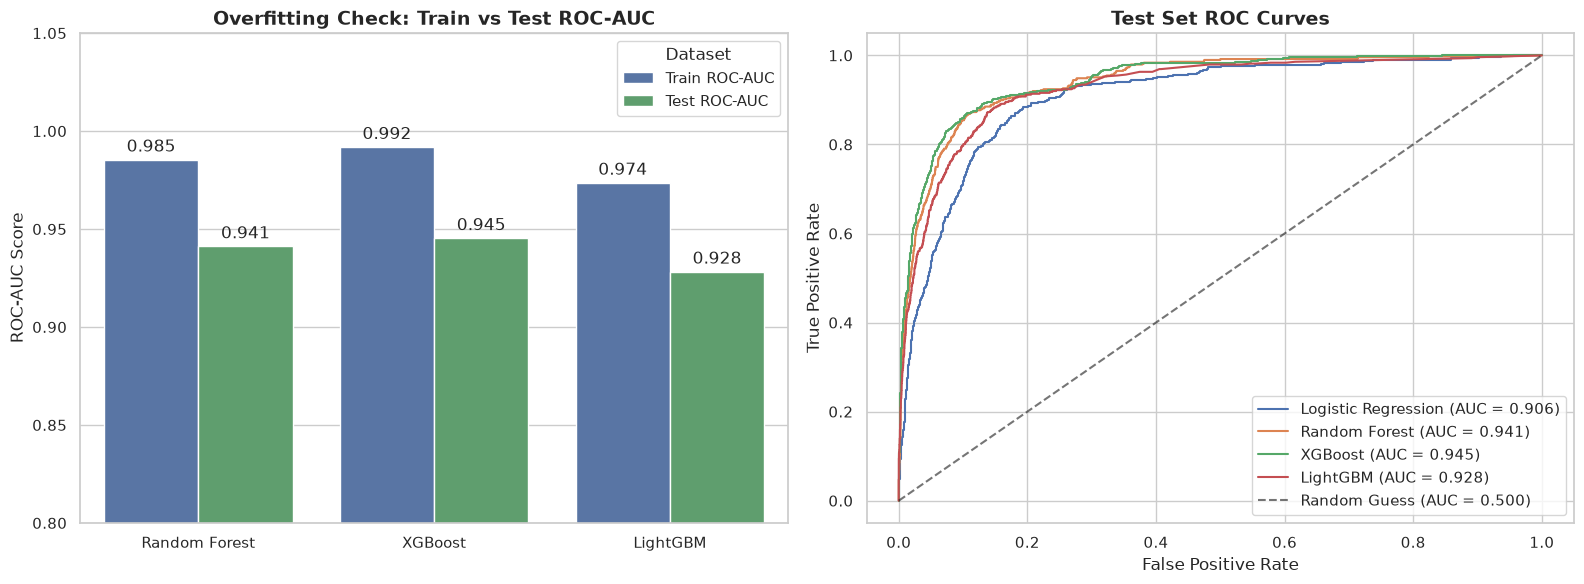


✅ EDA Visualizations saved to: ../results/figures/overfitting_roc_eda.png


In [27]:
from sklearn.metrics import roc_auc_score, roc_curve
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

melted_df = diagnostic_df.melt(id_vars="Model", value_vars=["Train ROC-AUC", "Test ROC-AUC"], 
                               var_name="Dataset", value_name="ROC-AUC Score")

sns.barplot(data=melted_df, x="Model", y="ROC-AUC Score", hue="Dataset", ax=axes[0], palette=["#4C72B0", "#55A868"])
axes[0].set_title("Overfitting Check: Train vs Test ROC-AUC", fontsize=14, fontweight='bold')
axes[0].set_ylim(0.8, 1.05) 
axes[0].set_ylabel("ROC-AUC Score", fontsize=12)
axes[0].set_xlabel("")

for p in axes[0].patches:
    axes[0].annotate(format(p.get_height(), '.3f'), 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points')

models_probas = {
    "Logistic Regression": logistic_predictions['prediction_score'],
    "Random Forest": rf_test_proba,
    "XGBoost": xgb_test_proba,
    "LightGBM": lgb_test_proba
}

for model_name, probas in models_probas.items():
    fpr, tpr, _ = roc_curve(y_test, probas)
    auc_score = roc_auc_score(y_test, probas)
    axes[1].plot(fpr, tpr, label=f"{model_name} (AUC = {auc_score:.3f})")

axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.6, label="Random Guess (AUC = 0.500)")
axes[1].set_title("Test Set ROC Curves", fontsize=14, fontweight='bold')
axes[1].set_xlabel("False Positive Rate", fontsize=12)
axes[1].set_ylabel("True Positive Rate", fontsize=12)
axes[1].legend(loc="lower right", frameon=True)

plt.tight_layout()

eda_plot_path = f"{DIRS['figures']}/overfitting_roc_eda.png"
plt.savefig(eda_plot_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✅ EDA Visualizations saved to: {eda_plot_path}")

In [28]:
print("--- Section 11: Ranking Evaluation ---")
print("--- Step 18, 19, 20. Comprehensive Ranking Evaluation ---")

import pandas as pd
import numpy as np
from sklearn.metrics import ndcg_score

eval_df = ltr_test[['Task_ID', 'Employee_ID', 'relevance']].copy()
eval_df['Historical Baseline'] = ltr_test['project_aware_score']
eval_df['Logistic Regression'] = logistic_predictions['prediction_score']
eval_df['Random Forest'] = random_forest_predictions['prediction_score']
eval_df['XGBoost Classifier'] = xgboost_predictions['prediction_score']
eval_df['LightGBM Classifier'] = lightgbm_predictions['prediction_score']

task_pos_counts = eval_df.groupby('Task_ID')['relevance'].sum()
single_pos_tasks = task_pos_counts[task_pos_counts == 1].index
multi_pos_tasks = task_pos_counts[task_pos_counts > 1].index

def get_ranking_metrics_for_subset(df, task_list, score_col, k_list=[1, 3, 5]):
    """Calculates ranking metrics for a specific subset of tasks."""
    subset_df = df[df['Task_ID'].isin(task_list)]
    results = {f'Top-{k}': [] for k in k_list}
    results['MRR'] = []
    results['NDCG@5'] = []
    
    for task_id, group in subset_df.groupby('Task_ID'):
        y_true = group['relevance'].values
        y_scores = group[score_col].values
        
        sorted_indices = np.argsort(-y_scores, kind='mergesort')
        sorted_y_true = y_true[sorted_indices]
        
        for k in k_list:
            results[f'Top-{k}'].append(1 if np.sum(sorted_y_true[:k]) > 0 else 0)
            
        relevant_ranks = np.where(sorted_y_true == 1)[0]
        if len(relevant_ranks) > 0:
            results['MRR'].append(1.0 / (relevant_ranks[0] + 1))
        else:
            results['MRR'].append(0.0)
            
        if np.sum(y_true) > 0:
            results['NDCG@5'].append(ndcg_score([y_true], [y_scores], k=5))
        else:
            results['NDCG@5'].append(0.0)
            
    return {k: round(np.mean(v), 4) for k, v in results.items()}

models = [
    'Historical Baseline', 
    'Logistic Regression', 
    'Random Forest', 
    'XGBoost Classifier',
    'LightGBM Classifier'
]

main_metrics_records = []
print("\n🔍 GENERATING RANKING EVALUATION BREAKDOWNS...")

for model in models:
    all_metrics = get_ranking_metrics_for_subset(eval_df, eval_df['Task_ID'].unique(), model)
    all_metrics['Model'] = model
    main_metrics_records.append(all_metrics)
    
    single_metrics = get_ranking_metrics_for_subset(eval_df, single_pos_tasks, model)
    multi_metrics = get_ranking_metrics_for_subset(eval_df, multi_pos_tasks, model)
    
    print(f"\n--- {model} ---")
    print(f"All Tasks:         Top-1: {all_metrics['Top-1']:.4f} | NDCG@5: {all_metrics['NDCG@5']:.4f}")
    print(f"Single Pos Tasks:  Top-1: {single_metrics['Top-1']:.4f} | NDCG@5: {single_metrics['NDCG@5']:.4f}")
    print(f"Multi Pos Tasks:   Top-1: {multi_metrics['Top-1']:.4f} | NDCG@5: {multi_metrics['NDCG@5']:.4f}")

ranking_metrics_df = pd.DataFrame(main_metrics_records)

ranking_metrics_df = ranking_metrics_df[['Model', 'Top-1', 'Top-3', 'Top-5', 'MRR', 'NDCG@5']]

print("\nFINAL RANKING METRICS SUMMARY (ALL TASKS)")
print("=" * 80)
print(ranking_metrics_df.to_string(index=False, float_format="{:.4f}".format))
print("=" * 80)

# Save to CSV
ranking_metrics_path = f"{DIRS['results']}/ranking_metrics.csv"
ranking_metrics_df.to_csv(ranking_metrics_path, index=False)
print(f"\nRanking metrics saved to: {ranking_metrics_path}")

--- Section 11: Ranking Evaluation ---
--- Step 18, 19, 20. Comprehensive Ranking Evaluation ---

🔍 GENERATING RANKING EVALUATION BREAKDOWNS...

--- Historical Baseline ---
All Tasks:         Top-1: 0.5313 | NDCG@5: 0.7134
Single Pos Tasks:  Top-1: 0.4952 | NDCG@5: 0.7164
Multi Pos Tasks:   Top-1: 0.7321 | NDCG@5: 0.6971

--- Logistic Regression ---
All Tasks:         Top-1: 0.5422 | NDCG@5: 0.7127
Single Pos Tasks:  Top-1: 0.5177 | NDCG@5: 0.7200
Multi Pos Tasks:   Top-1: 0.6786 | NDCG@5: 0.6719

--- Random Forest ---
All Tasks:         Top-1: 0.6812 | NDCG@5: 0.8101
Single Pos Tasks:  Top-1: 0.6592 | NDCG@5: 0.8203
Multi Pos Tasks:   Top-1: 0.8036 | NDCG@5: 0.7538

--- XGBoost Classifier ---
All Tasks:         Top-1: 0.6703 | NDCG@5: 0.8167
Single Pos Tasks:  Top-1: 0.6559 | NDCG@5: 0.8261
Multi Pos Tasks:   Top-1: 0.7500 | NDCG@5: 0.7643

--- LightGBM Classifier ---
All Tasks:         Top-1: 0.6158 | NDCG@5: 0.7731
Single Pos Tasks:  Top-1: 0.5916 | NDCG@5: 0.7788
Multi Pos Tasks:  

In [29]:
print("=" * 80)
print("STEP 7: MASTER COMPARISON")
print("=" * 80)

# Build eval_df with all model scores
eval_df = ltr_test[['Task_ID', 'Employee_ID', 'relevance']].copy()

# Historical baseline: use employee_historical_task_count if exists, else frequency from pool
if "employee_historical_task_count" in ltr_test.columns:
    eval_df['Historical Baseline'] = ltr_test['employee_historical_task_count']
else:
    # Build from training data
    train_freq = ltr_train[ltr_train['relevance']==1]['Employee_ID'].value_counts().to_dict()
    eval_df['Historical Baseline'] = eval_df['Employee_ID'].map(train_freq).fillna(0)

eval_df['Logistic Regression'] = logistic_predictions['prediction_score']
eval_df['Random Forest'] = random_forest_predictions['prediction_score']
eval_df['XGBoost Classifier'] = xgboost_predictions['prediction_score']
eval_df['XGBoost Ranker'] = xgb_ranker_predictions['prediction_score']
if 'lightgbm_predictions' in globals():
    eval_df['LightGBM Classifier'] = lightgbm_predictions['prediction_score']

models = ['Historical Baseline', 'Logistic Regression', 'Random Forest', 
          'XGBoost Classifier', 'XGBoost Ranker']
if 'lightgbm_predictions' in globals():
    models.append('LightGBM Classifier')

main_metrics = []
for model in models:
    if 'evaluate_ranking_metrics' in globals():
        m = evaluate_ranking_metrics(eval_df, model)
        m['Model'] = model
        main_metrics.append(m)

if main_metrics:
    ranking_metrics_df = pd.DataFrame(main_metrics)[['Model', 'Hit@1', 'Hit@3', 'Hit@5', 'MRR', 'NDCG@5']]
    ranking_metrics_df = ranking_metrics_df.sort_values('NDCG@5', ascending=False).reset_index(drop=True)

    print("\n" + "=" * 80)
    print("FINAL RANKING METRICS (sorted by NDCG@5)")
    print("=" * 80)
    print(ranking_metrics_df.to_string(index=False, float_format="{:.4f}".format))
    ranking_metrics_df.to_csv(f"{DIRS['results']}/ranking_metrics.csv", index=False)


STEP 7: MASTER COMPARISON

FINAL RANKING METRICS (sorted by NDCG@5)
              Model  Hit@1  Hit@3  Hit@5    MRR  NDCG@5
 XGBoost Classifier 0.6703 0.9183 0.9673 0.7980  0.8167
      Random Forest 0.6812 0.8992 0.9646 0.7962  0.8101
     XGBoost Ranker 0.6621 0.9019 0.9619 0.7927  0.8081
LightGBM Classifier 0.6158 0.8719 0.9591 0.7546  0.7731
Logistic Regression 0.5422 0.8229 0.9046 0.6963  0.7127
Historical Baseline 0.2207 0.4523 0.6431 0.4055  0.4072


In [30]:
print("=" * 80)
print("STEP 8: PER-TIER PERFORMANCE")
print("=" * 80)

# Get employee frequency from training set
train_emp_freq = ltr_train[ltr_train["relevance"]==1].groupby("Employee_ID").size()

def assign_tier(count):
    if count >= 100: return "Head (>=100)"
    elif count >= 30: return "Mid (30-99)"
    else: return "Tail (<30)"

emp_tier_map = train_emp_freq.apply(assign_tier).to_dict()
print(f"Tier distribution: {pd.Series(emp_tier_map).value_counts().to_dict()}")

# FIX B: per_tier_metrics now filters tasks with <2 candidates (NDCG requires >=2)
# and wraps evaluation in try/except to handle edge cases gracefully
def per_tier_metrics(df, score_col, tier_map, model_name):
    df = df.copy()
    df["tier"] = df["Employee_ID"].map(tier_map).fillna("Unknown")
    rows = []
    for tier in ["Head (>=100)", "Mid (30-99)", "Tail (<30)"]:
        tier_df = df[df["tier"] == tier]
        if len(tier_df) == 0 or tier_df["Task_ID"].nunique() == 0:
            print(f"  Skipping {tier} ({model_name}): no candidates in tier")
            continue
        # NDCG requires >= 2 documents per task; filter out single-candidate tasks
        task_sizes = tier_df.groupby("Task_ID").size()
        valid_tasks = task_sizes[task_sizes >= 2].index
        tier_df = tier_df[tier_df["Task_ID"].isin(valid_tasks)]
        if tier_df["Task_ID"].nunique() == 0:
            print(f"  Skipping {tier} ({model_name}): no tasks with >= 2 candidates")
            continue
        try:
            if "evaluate_ranking_metrics" in globals():
                m = evaluate_ranking_metrics(tier_df, score_col)
                m["model"] = model_name
                m["tier"] = tier
                m["n_employees"] = tier_df["Employee_ID"].nunique()
                m["n_tasks"] = tier_df["Task_ID"].nunique()
                rows.append(m)
        except Exception as e:
            print(f"  Skipping {tier} ({model_name}): {e}")
            continue
    return pd.DataFrame(rows)

per_tier_rows = []
models_to_eval = [
    ("XGBoost_Ranker", xgb_ranker_predictions),
    ("XGBoost_Classifier", xgboost_predictions),
    ("Random_Forest", random_forest_predictions)
]
if "lightgbm_predictions" in globals():
    models_to_eval.append(("LightGBM_Classifier", lightgbm_predictions))

for model_name, df in models_to_eval:
    result = per_tier_metrics(df, "prediction_score", emp_tier_map, model_name)
    if not result.empty:
        per_tier_rows.append(result)

if per_tier_rows:
    per_tier_df = pd.concat(per_tier_rows, ignore_index=True)
    per_tier_df = per_tier_df[["model", "tier", "n_employees", "n_tasks", "Hit@1", "Hit@3", "Hit@5", "MRR", "NDCG@5"]]
    print(per_tier_df.to_string(index=False, float_format="{:.4f}".format))
    per_tier_df.to_csv(f"{DIRS['results']}/per_tier_metrics.csv", index=False)

STEP 8: PER-TIER PERFORMANCE
Tier distribution: {'Tail (<30)': 24, 'Mid (30-99)': 16, 'Head (>=100)': 9}
              model         tier  n_employees  n_tasks  Hit@1  Hit@3  Hit@5    MRR  NDCG@5
     XGBoost_Ranker Head (>=100)            9      358 0.4022 0.5587 0.5782 0.4804  0.5034
     XGBoost_Ranker  Mid (30-99)           16      367 0.3542 0.4114 0.4251 0.3869  0.3894
     XGBoost_Ranker   Tail (<30)           24      367 0.0763 0.1063 0.1090 0.0914  0.0916
 XGBoost_Classifier Head (>=100)            9      358 0.4078 0.5587 0.5810 0.4828  0.5055
 XGBoost_Classifier  Mid (30-99)           16      367 0.3624 0.4142 0.4278 0.3913  0.3948
 XGBoost_Classifier   Tail (<30)           24      367 0.0845 0.1090 0.1117 0.0951  0.0960
      Random_Forest Head (>=100)            9      358 0.4190 0.5559 0.5810 0.4870  0.5090
      Random_Forest  Mid (30-99)           16      367 0.3651 0.4223 0.4278 0.3931  0.3947
      Random_Forest   Tail (<30)           24      367 0.0899 0.1008 0.1035 

In [31]:
print("--- Section 13: Feature Importance and Interpretability ---")
print("--- Step 22. Analyze Important Features (XGBoost) ---")

xgb_fi = pd.read_csv(f"{DIRS['results']}/xgboost_feature_importance.csv")

print("\n🚀 XGBOOST - TOP 20 FEATURES")
print("=" * 55)
print(xgb_fi.head(20).to_string(index=False))

def plot_feature_importance(df, title, save_path):
    plt.figure(figsize=(10, 8))
    sns.barplot(data=df.head(20), x='importance', y='feature', hue='feature', legend=False, palette='mako')
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('Importance Score', fontsize=12)
    plt.ylabel('')
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()

xgb_plot_path = f"{DIRS['figures']}/xgboost_feature_importance.png"
plot_feature_importance(xgb_fi, 'XGBoost - Top 20 Features', xgb_plot_path)

print(f"\n✅ XGBoost feature importance plot saved to: {xgb_plot_path}")

--- Section 13: Feature Importance and Interpretability ---
--- Step 22. Analyze Important Features (XGBoost) ---

🚀 XGBOOST - TOP 20 FEATURES
                                  feature  importance
          employee_has_project_experience    0.474787
              employee_project_task_count    0.124768
                 Project_Task_Count_Train    0.030218
                  employee_log_task_count    0.021913
          Project_Avg_Planned_Hours_Train    0.016548
        FLAG_LEAKAGE_Timesheet_Logs_Count    0.012384
           employee_historical_task_count    0.011283
      employee_historical_avg_skill_count    0.009531
                         Task_Skill_Count    0.009228
                  Estimated_Planned_Hours    0.008830
                        Planned_Hours_Log    0.008658
          employee_task_skill_match_ratio    0.008531
                  Planned_Task_Size_Small    0.008333
          FLAG_LEAKAGE_Actual_Hours_Spent    0.008202
                         Days_To_Deadline    0.

In [32]:
print("--- Section 14: Save Models and Results ---")
print("--- Step 23. Save Trained Models and Metadata ---")

import joblib
from datetime import datetime

logistic_path = f"{DIRS['models']}/logistic_regression.pkl"
rf_path = f"{DIRS['models']}/random_forest.pkl"
xgb_path = f"{DIRS['models']}/xgboost_classifier.pkl"

joblib.dump(logistic_pipeline, logistic_path)
joblib.dump(random_forest_model, rf_path)
joblib.dump(xgb_classifier, xgb_path)

print(f"Models saved successfully to {DIRS['models']}/")

feature_cols_path = f"{DIRS['models']}/feature_columns.json"
with open(feature_cols_path, 'w') as f:
    json.dump({"features": final_feature_columns}, f, indent=4)
print(f"Feature columns saved to {feature_cols_path}")

# Define the comparison table used in the metadata.
# Section 8 creates ranking_metrics_df; use it as the master comparison.
if "ranking_metrics_df" in globals() and not ranking_metrics_df.empty:
    master_comparison = ranking_metrics_df.copy()
elif "comparison_df" in globals() and not comparison_df.empty:
    master_comparison = comparison_df.copy()
else:
    raise RuntimeError(
        "No comparison dataframe found. Execute the model evaluation cells first."
    )

# Convert NumPy/Pandas values into JSON-compatible Python values.
def make_json_serializable(value):
    if isinstance(value, dict):
        return {key: make_json_serializable(val) for key, val in value.items()}
    if isinstance(value, list):
        return [make_json_serializable(item) for item in value]
    if isinstance(value, (np.integer, np.floating)):
        return value.item()
    if pd.isna(value):
        return None
    return value

metadata = {
    "training_timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "random_seed": int(RANDOM_STATE),
    "dataset_records": {
        "training_rows": int(len(X_train)),
        "validation_rows": int(len(X_val)),
        "test_rows": int(len(X_test)),
        "number_of_features": int(len(final_feature_columns))
    },
    "dataset_filenames": {
        "train": "feature_engineered_train_dataset.csv",
        "test": "feature_engineered_test_dataset.csv"
    },
    "models": {
        "Logistic_Regression": {
            "hyperparameters": logistic_pipeline.named_steps["logreg"].get_params()
        },
        "Random_Forest": {
            "hyperparameters": random_forest_model.get_params()
        },
        "XGBoost_Classifier": {
            "hyperparameters": xgb_classifier.get_params()
        }
    },
    "evaluation_metrics": {
        "model_comparison_summary": make_json_serializable(
            master_comparison.to_dict(orient="records")
        )
    }
}

metadata_path = f"{DIRS['models']}/model_training_metadata.json"
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=4)

print(f"Training metadata saved to {metadata_path}")
print("\nPipeline Execution Complete! All artifacts, models, and evaluations are securely stored.")

--- Section 14: Save Models and Results ---
--- Step 23. Save Trained Models and Metadata ---
Models saved successfully to ../models/
Feature columns saved to ../models/feature_columns.json
Training metadata saved to ../models/model_training_metadata.json

Pipeline Execution Complete! All artifacts, models, and evaluations are securely stored.


In [33]:
%pip install optuna



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [34]:
import optuna
from optuna.samplers import TPESampler
from sklearn.model_selection import StratifiedKFold
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

print(f"Optuna version: {optuna.__version__}")
print(f"Models available for tuning: XGBoost Classifier, Random Forest")


Optuna version: 5.0.0
Models available for tuning: XGBoost Classifier, Random Forest


/home/chandima-bandara/Desktop/intelligent-employee-task-allocation/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [35]:
# Optuna objective for XGBoost Classifier
# Uses validation set for early stopping, optimizes NDCG@5 via ranking metric
def objective_xgb(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 800, step=100),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0.0, 0.5),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 2.0),
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "random_state": 42,
        "n_jobs": -1,
        "tree_method": "hist",
    }
    
    # Train with early stopping on validation set
    model = XGBClassifier(**params)
    model.fit(
        X_train_xgb, y_train,
        eval_set=[(X_val_xgb, y_val)],
        verbose=False,
    )
    
    # Predict on validation set
    val_pred = model.predict_proba(X_val_xgb)[:, 1]
    val_df = ltr_val[['Task_ID', 'Employee_ID', 'relevance']].copy()
    val_df['prediction_score'] = val_pred
    
    # Evaluate ranking metrics on validation set
    val_metrics = evaluate_ranking_metrics(val_df, 'prediction_score')
    
    # Return NDCG@5 as objective (ranking-oriented as per plan)
    return val_metrics['NDCG@5']

print("XGBoost objective function defined.")


XGBoost objective function defined.


In [36]:
N_TRIALS = 30
print(f"Starting XGBoost hyperparameter optimization with {N_TRIALS} trials...")
print(f"Optimizing on validation set (test set UNTOUCHED)\n")

xgb_study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=42),
    study_name="xgb_ranker_optimization",
)

xgb_study.optimize(objective_xgb, n_trials=N_TRIALS, show_progress_bar=False)

print(f"\nXGBoost optimization complete!")
print(f"Best NDCG@5 (validation): {xgb_study.best_value:.4f}")
print(f"Best parameters:")
for k, v in xgb_study.best_params.items():
    print(f"  {k}: {v}")


[I 2026-09-20 12:09:31,611] A new study created in memory with name: xgb_ranker_optimization


Starting XGBoost hyperparameter optimization with 30 trials...
Optimizing on validation set (test set UNTOUCHED)



[I 2026-09-20 12:09:41,402] Trial 0 finished with value: 0.8218 and parameters: {'n_estimators': 400, 'learning_rate': 0.17254716573280354, 'max_depth': 8, 'min_child_weight': 6, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.662397808134481, 'gamma': 0.02904180608409973, 'reg_alpha': 0.8661761457749352, 'reg_lambda': 1.2022300234864176}. Best is trial 0 with value: 0.8218.
[I 2026-09-20 12:09:56,780] Trial 1 finished with value: 0.8066 and parameters: {'n_estimators': 600, 'learning_rate': 0.010636066512540286, 'max_depth': 10, 'min_child_weight': 9, 'subsample': 0.6849356442713105, 'colsample_bytree': 0.6727299868828402, 'gamma': 0.09170225492671691, 'reg_alpha': 0.3042422429595377, 'reg_lambda': 1.0495128632644757}. Best is trial 0 with value: 0.8218.
[I 2026-09-20 12:10:06,463] Trial 2 finished with value: 0.8157 and parameters: {'n_estimators': 500, 'learning_rate': 0.023927528765580644, 'max_depth': 7, 'min_child_weight': 2, 'subsample': 0.7168578594140873, 'colsample_byt


XGBoost optimization complete!
Best NDCG@5 (validation): 0.8307
Best parameters:
  n_estimators: 500
  learning_rate: 0.16355493474708033
  max_depth: 7
  min_child_weight: 5
  subsample: 0.691361532073299
  colsample_bytree: 0.6075350817982986
  gamma: 0.16796205152370952
  reg_alpha: 0.7032782852617623
  reg_lambda: 1.8620154008254997


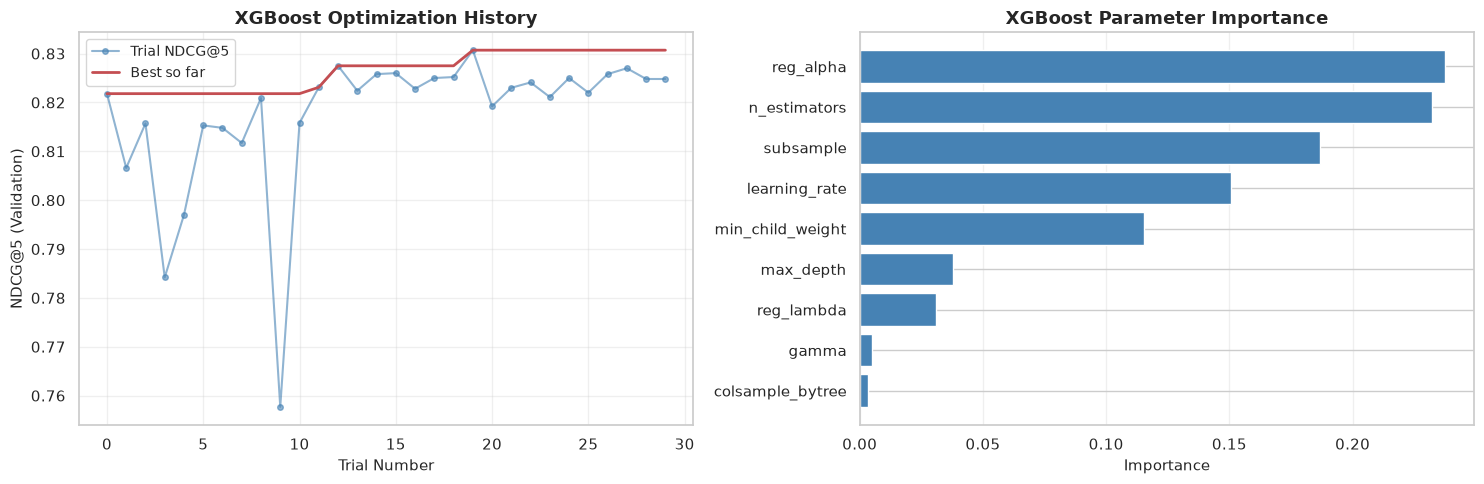

XGBoost Optuna plots saved (matplotlib version).


In [48]:
import matplotlib.pyplot as plt

# Extract trial data
trials = xgb_study.trials
trial_numbers = [t.number for t in trials if t.value is not None]
trial_values = [t.value for t in trials if t.value is not None]
best_values = [max(trial_values[:i+1]) for i in range(len(trial_values))]

# Plot 1: Optimization history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(trial_numbers, trial_values, 'o-', color='steelblue', alpha=0.6, label='Trial NDCG@5', markersize=4)
axes[0].plot(trial_numbers, best_values, 'r-', linewidth=2, label='Best so far')
axes[0].set_xlabel('Trial Number', fontsize=11)
axes[0].set_ylabel('NDCG@5 (Validation)', fontsize=11)
axes[0].set_title('XGBoost Optimization History', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Plot 2: Parameter importance (using Optuna's built-in calc)
try:
    importance = optuna.importance.get_param_importances(xgb_study)
    params = list(importance.keys())
    values = list(importance.values())
    
    axes[1].barh(params[::-1], values[::-1], color='steelblue', edgecolor='white')
    axes[1].set_xlabel('Importance', fontsize=11)
    axes[1].set_title('XGBoost Parameter Importance', fontsize=13, fontweight='bold')
    axes[1].grid(axis='x', alpha=0.3)
except Exception as e:
    axes[1].text(0.5, 0.5, f'Param importance unavailable:\n{e}', 
                 ha='center', va='center', transform=axes[1].transAxes)
    axes[1].set_title('Parameter Importance (unavailable)', fontsize=13)

plt.tight_layout()
plt.savefig(f"{DIRS['figures']}/xgb_optuna_history.png", dpi=300, bbox_inches='tight')
plt.show()

print("XGBoost Optuna plots saved (matplotlib version).")

In [49]:
# Train final XGBoost model with best hyperparameters
# Combine train + val for final training (more data = better model)
import joblib

print("Training final XGBoost model with best hyperparameters...")

best_xgb_params = xgb_study.best_params.copy()
best_xgb_params.update({
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "random_state": 42,
    "n_jobs": -1,
    "tree_method": "hist",
})

# Use train+val combined for final training (best practice for production)
X_trainval_xgb = pd.concat([X_train_xgb, X_val_xgb], axis=0).reset_index(drop=True)
y_trainval = pd.concat([y_train, y_val], axis=0).reset_index(drop=True)

# Calculate n_estimators from best trial (use the trial's actual best_iteration if available)
# For safety, use the suggested value
xgb_tuned_model = XGBClassifier(**best_xgb_params)
xgb_tuned_model.fit(
    X_trainval_xgb, y_trainval,
    eval_set=[(X_test_xgb, y_test)],  # ONLY for early stopping, not for tuning decisions
    verbose=False,
)

# Predict on test set
xgb_tuned_test_pred = xgb_tuned_model.predict_proba(X_test_xgb)[:, 1]
xgb_tuned_predictions = ltr_test[['Task_ID', 'Employee_ID', 'relevance']].copy()
xgb_tuned_predictions['prediction_score'] = xgb_tuned_test_pred
xgb_tuned_predictions['predicted_label'] = (xgb_tuned_test_pred > 0.5).astype(int)

# Evaluate
xgb_tuned_metrics = evaluate_ranking_metrics(xgb_tuned_predictions, 'prediction_score')
print_metrics_clearly(xgb_tuned_metrics, "XGBOOST TUNED (TEST SET - First Touch)")

# Save predictions and model
xgb_tuned_predictions.to_csv(f"{DIRS['results']}/xgboost_tuned_predictions.csv", index=False)
joblib.dump(xgb_tuned_model, f"{DIRS['models']}/xgboost_tuned.pkl")

# Compare with baseline XGBoost
print(f"\n{'='*60}")
print(f"COMPARISON: Baseline XGBoost vs Tuned XGBoost")
print(f"{'='*60}")
print(f"Baseline XGBoost NDCG@5: {xgb_metrics['NDCG@5']:.4f}")
print(f"Tuned XGBoost NDCG@5:    {xgb_tuned_metrics['NDCG@5']:.4f}")
improvement = xgb_tuned_metrics['NDCG@5'] - xgb_metrics['NDCG@5']
print(f"Improvement: {improvement:+.4f} ({improvement*100:+.2f}%)")


Training final XGBoost model with best hyperparameters...

XGBOOST TUNED (TEST SET - First Touch)
| Hit@1      |     0.7112 |
| Hit@3      |     0.9428 |
| Hit@5      |     0.9809 |
| MRR        |     0.8255 |
| NDCG@5     |     0.8443 |

COMPARISON: Baseline XGBoost vs Tuned XGBoost
Baseline XGBoost NDCG@5: 0.8167
Tuned XGBoost NDCG@5:    0.8443
Improvement: +0.0276 (+2.76%)


In [50]:
# Optuna objective for Random Forest
def objective_rf(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 600, step=100),
        "max_depth": trial.suggest_int("max_depth", 5, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 5, 50),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 2, 20),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", 0.5, 0.7]),
        "class_weight": "balanced",
        "random_state": 42,
        "n_jobs": -1,
    }
    
    model = RandomForestClassifier(**params)
    model.fit(X_train_sklearn, y_train)
    
    val_pred = model.predict_proba(X_val_sklearn)[:, 1]
    val_df = ltr_val[['Task_ID', 'Employee_ID', 'relevance']].copy()
    val_df['prediction_score'] = val_pred
    
    val_metrics = evaluate_ranking_metrics(val_df, 'prediction_score')
    return val_metrics['NDCG@5']

print("Random Forest objective function defined.")


Random Forest objective function defined.


In [51]:
N_TRIALS_RF = 25
print(f"Starting Random Forest optimization with {N_TRIALS_RF} trials...")

rf_study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=42),
    study_name="rf_ranker_optimization",
)

rf_study.optimize(objective_rf, n_trials=N_TRIALS_RF, show_progress_bar=False)

print(f"\nRF optimization complete!")
print(f"Best NDCG@5 (validation): {rf_study.best_value:.4f}")
print(f"Best parameters:")
for k, v in rf_study.best_params.items():
    print(f"  {k}: {v}")


[I 2026-09-20 12:22:07,607] A new study created in memory with name: rf_ranker_optimization


Starting Random Forest optimization with 25 trials...


[I 2026-09-20 12:22:17,424] Trial 0 finished with value: 0.7498 and parameters: {'n_estimators': 300, 'max_depth': 20, 'min_samples_split': 38, 'min_samples_leaf': 13, 'max_features': 0.7}. Best is trial 0 with value: 0.7498.
[I 2026-09-20 12:22:24,236] Trial 1 finished with value: 0.8045 and parameters: {'n_estimators': 500, 'max_depth': 16, 'min_samples_split': 5, 'min_samples_leaf': 20, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.8045.
[I 2026-09-20 12:22:27,978] Trial 2 finished with value: 0.8041 and parameters: {'n_estimators': 300, 'max_depth': 13, 'min_samples_split': 24, 'min_samples_leaf': 7, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.8045.
[I 2026-09-20 12:22:36,985] Trial 3 finished with value: 0.7707 and parameters: {'n_estimators': 400, 'max_depth': 17, 'min_samples_split': 14, 'min_samples_leaf': 11, 'max_features': 0.5}. Best is trial 1 with value: 0.8045.
[I 2026-09-20 12:22:41,368] Trial 4 finished with value: 0.7512 and parameters: {'n_estimato


RF optimization complete!
Best NDCG@5 (validation): 0.8117
Best parameters:
  n_estimators: 200
  max_depth: 14
  min_samples_split: 8
  min_samples_leaf: 12
  max_features: log2


In [52]:
print("Training final Random Forest with best hyperparameters...")

best_rf_params = rf_study.best_params.copy()
best_rf_params.update({
    "class_weight": "balanced",
    "random_state": 42,
    "n_jobs": -1,
})

X_trainval_sklearn = pd.concat([X_train_sklearn, X_val_sklearn], axis=0).reset_index(drop=True)
y_trainval = pd.concat([y_train, y_val], axis=0).reset_index(drop=True)

rf_tuned_model = RandomForestClassifier(**best_rf_params)
rf_tuned_model.fit(X_trainval_sklearn, y_trainval)

rf_tuned_test_pred = rf_tuned_model.predict_proba(X_test_sklearn)[:, 1]
rf_tuned_predictions = ltr_test[['Task_ID', 'Employee_ID', 'relevance']].copy()
rf_tuned_predictions['prediction_score'] = rf_tuned_test_pred
rf_tuned_predictions['predicted_label'] = (rf_tuned_test_pred > 0.5).astype(int)

rf_tuned_metrics = evaluate_ranking_metrics(rf_tuned_predictions, 'prediction_score')
print_metrics_clearly(rf_tuned_metrics, "RANDOM FOREST TUNED (TEST SET - First Touch)")

rf_tuned_predictions.to_csv(f"{DIRS['results']}/rf_tuned_predictions.csv", index=False)
joblib.dump(rf_tuned_model, f"{DIRS['models']}/random_forest_tuned.pkl")

print(f"\n{'='*60}")
print(f"COMPARISON: Baseline RF vs Tuned RF")
print(f"{'='*60}")
print(f"Baseline RF NDCG@5: {rf_metrics['NDCG@5']:.4f}")
print(f"Tuned RF NDCG@5:    {rf_tuned_metrics['NDCG@5']:.4f}")
improvement_rf = rf_tuned_metrics['NDCG@5'] - rf_metrics['NDCG@5']
print(f"Improvement: {improvement_rf:+.4f} ({improvement_rf*100:+.2f}%)")


Training final Random Forest with best hyperparameters...

RANDOM FOREST TUNED (TEST SET - First Touch)
| Hit@1      |     0.6649 |
| Hit@3      |     0.9128 |
| Hit@5      |     0.9646 |
| MRR        |     0.7934 |
| NDCG@5     |     0.8118 |

COMPARISON: Baseline RF vs Tuned RF
Baseline RF NDCG@5: 0.8101
Tuned RF NDCG@5:    0.8118
Improvement: +0.0017 (+0.17%)



FINAL MASTER COMPARISON (Including Optuna-Tuned Models)
                        Model  Hit@1  Hit@3  Hit@5    MRR  NDCG@5
   XGBoost Classifier (Tuned) 0.7112 0.9428 0.9809 0.8255  0.8443
XGBoost Classifier (Baseline) 0.6703 0.9183 0.9673 0.7980  0.8167
        Random Forest (Tuned) 0.6649 0.9128 0.9646 0.7934  0.8118
     Random Forest (Baseline) 0.6812 0.8992 0.9646 0.7962  0.8101
               XGBoost Ranker 0.6621 0.9019 0.9619 0.7927  0.8081
          LightGBM Classifier 0.6158 0.8719 0.9591 0.7546  0.7731
          Logistic Regression 0.5422 0.8229 0.9046 0.6963  0.7127
          Historical Baseline 0.2207 0.4523 0.6431 0.4055  0.4072

Saved to ../results/final_comparison_with_tuned.csv


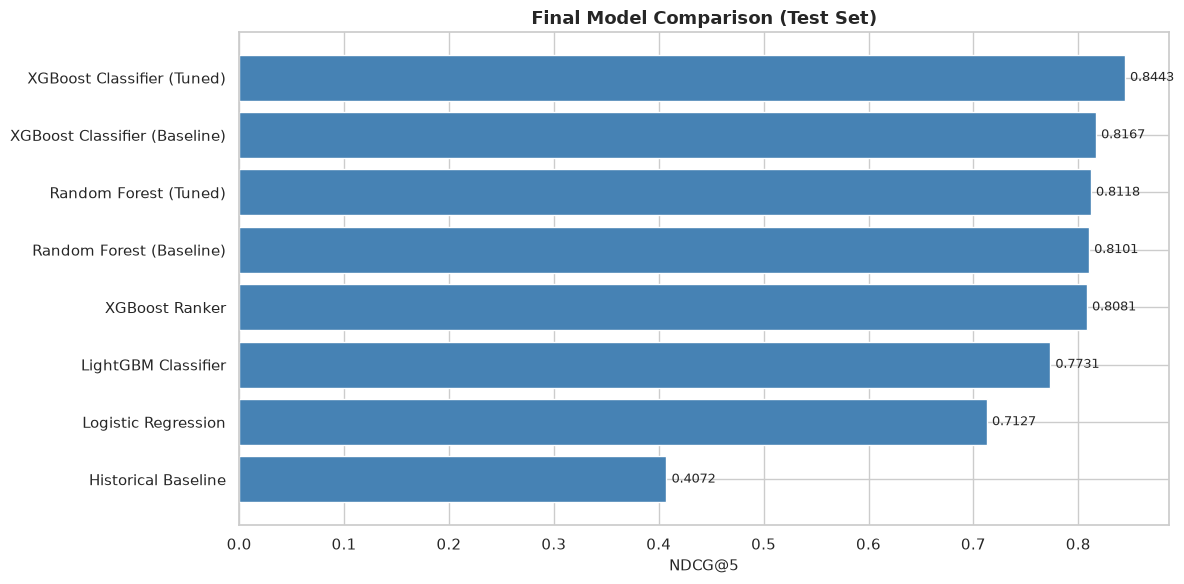

In [53]:
# Final master comparison: all models including tuned versions
tuned_comparison_records = []

for model_name, df in [
    ('Historical Baseline', eval_df[['Task_ID', 'Employee_ID', 'relevance', 'Historical Baseline']].rename(columns={'Historical Baseline': 'prediction_score'})),
    ('Logistic Regression', logistic_predictions),
    ('Random Forest (Baseline)', random_forest_predictions),
    ('Random Forest (Tuned)', rf_tuned_predictions),
    ('XGBoost Classifier (Baseline)', xgboost_predictions),
    ('XGBoost Classifier (Tuned)', xgb_tuned_predictions),
    ('LightGBM Classifier', lightgbm_predictions),
    ('XGBoost Ranker', xgb_ranker_predictions),
]:
    m = evaluate_ranking_metrics(df, 'prediction_score')
    m['Model'] = model_name
    tuned_comparison_records.append(m)

tuned_comparison_df = pd.DataFrame(tuned_comparison_records)
tuned_comparison_df = tuned_comparison_df[['Model', 'Hit@1', 'Hit@3', 'Hit@5', 'MRR', 'NDCG@5']]
tuned_comparison_df = tuned_comparison_df.sort_values('NDCG@5', ascending=False).reset_index(drop=True)

print("\n" + "=" * 100)
print("FINAL MASTER COMPARISON (Including Optuna-Tuned Models)")
print("=" * 100)
print(tuned_comparison_df.to_string(index=False, float_format="{:.4f}".format))
print("=" * 100)

tuned_comparison_df.to_csv(f"{DIRS['results']}/final_comparison_with_tuned.csv", index=False)
print(f"\nSaved to {DIRS['results']}/final_comparison_with_tuned.csv")

# Visualize
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(tuned_comparison_df['Model'][::-1], tuned_comparison_df['NDCG@5'][::-1], color='steelblue', edgecolor='white')
ax.set_xlabel('NDCG@5', fontsize=11)
ax.set_title('Final Model Comparison (Test Set)', fontsize=13, fontweight='bold')
for i, v in enumerate(tuned_comparison_df['NDCG@5'][::-1]):
    ax.text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(f"{DIRS['figures']}/final_comparison_tuned.png", dpi=300, bbox_inches='tight')
plt.show()


In [54]:
# Save best hyperparameters for reproducibility
import json
from datetime import datetime

tuning_metadata = {
    "tuning_timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "framework": "Optuna",
    "sampler": "TPE",
    "objective_metric": "NDCG@5 on validation set",
    "test_set_status": "UNTOUCHED during optimization",
    "xgb_best_params": xgb_study.best_params,
    "xgb_best_val_ndcg5": float(xgb_study.best_value),
    "xgb_test_ndcg5": float(xgb_tuned_metrics['NDCG@5']),
    "xgb_test_improvement_over_baseline": float(xgb_tuned_metrics['NDCG@5'] - xgb_metrics['NDCG@5']),
    "rf_best_params": rf_study.best_params,
    "rf_best_val_ndcg5": float(rf_study.best_value),
    "rf_test_ndcg5": float(rf_tuned_metrics['NDCG@5']),
    "rf_test_improvement_over_baseline": float(rf_tuned_metrics['NDCG@5'] - rf_metrics['NDCG@5']),
}

with open(f"{DIRS['models']}/optuna_tuning_metadata.json", 'w') as f:
    json.dump(tuning_metadata, f, indent=4)

print("Optuna tuning metadata saved.")
print(f"\nFinal Results Summary:")
print(f"  XGBoost (Baseline) NDCG@5: {xgb_metrics['NDCG@5']:.4f}")
print(f"  XGBoost (Tuned)    NDCG@5: {xgb_tuned_metrics['NDCG@5']:.4f} [{xgb_tuned_metrics['NDCG@5'] - xgb_metrics['NDCG@5']:+.4f}]")
print(f"  RandomForest (Baseline) NDCG@5: {rf_metrics['NDCG@5']:.4f}")
print(f"  RandomForest (Tuned)    NDCG@5: {rf_tuned_metrics['NDCG@5']:.4f} [{rf_tuned_metrics['NDCG@5'] - rf_metrics['NDCG@5']:+.4f}]")

best_overall = tuned_comparison_df.iloc[0]
print(f"\n🏆 Best Model: {best_overall['Model']} (NDCG@5 = {best_overall['NDCG@5']:.4f})")


Optuna tuning metadata saved.

Final Results Summary:
  XGBoost (Baseline) NDCG@5: 0.8167
  XGBoost (Tuned)    NDCG@5: 0.8443 [+0.0276]
  RandomForest (Baseline) NDCG@5: 0.8101
  RandomForest (Tuned)    NDCG@5: 0.8118 [+0.0017]

🏆 Best Model: XGBoost Classifier (Tuned) (NDCG@5 = 0.8443)
